## Q. No. 1 RNN Fundamentals
### a) The concept of hidden states and how they enable memory in RNNs
In RNN, hidden state performs as a memory of previous inputs in a sequence, it update the hidden state from current input and  previous hidden state which means it memorys the previous information across the time steps instead of just consider the current information.  However, traditional feedforward neural networks can not capture the temporal information.
### b) The mathematical formulation of a simple RNN cell.
* Hidden state:
    $h_t = \text{tanh}(W_{xh}x_t + W_{hh}h_{t-1} + b_h)$
* Output:
    $y_t = W_{hy}h_t + b_y$

Where:
* $x_t$: input at time step $t$
* $h_t$: hidden state at time step $t$
* $W_{xh}, W_{hh}, W_{hy}$: weight matrices
* $b_h, b_y$: bias vectors
* tanh: activation function


### c) The vanishing gradient problem in RNNs and how it affects learning long-term dependencies. 
When training RNNs, because of it uses hidden state, the gradient on backpropagation go across many time steps, so the gradient will become too small if the sequence is really long. So if the sequence is too long, the gradient vanished, RNNs can not capture long-term dependencies.

### d) One common variant of RNN that addresses this problem (LSTM or GRU)
LSTM can deal with the vanishing of the gradient. It uses gated mechanisms. It consists of forget gate(decide the information to forget), input gate(contol the information to add), output gate(decide which part to output). Gated mechanisms can select the memory which making the information be kept over long sequences.


## Q. No. 2 Sequence Modeling Applications
### 1. robot motion prediction
a) Explain why sequential data is important in this context?

When the robot is moving, the motion is dependent. Each action depends on the previous motion so the motion is a sequence data.

b) What type of RNN architecture would be most appropriate?

LSTM would be appropriate as it can capture long-term dependencies.

c) What preprocessing might be needed for the sequential data?

For each action we need to encode it into vectors.

### 2.medication recommendation from prescription history
a) Explain why sequential data is important in this context?

The prescription history of a patient is sequential as it contain the information that will influence the future medication decisions.

b) What type of RNN architecture would be most appropriate?

Bidirectional GRU is appropriate as it captures the past and future context to have a better prediction performance.

c) What preprocessing might be needed for the sequential data?

The categories of the medication need to be encoded.

### 3.Trajectory prediction for vehicles
a) Explain why sequential data is important in this context?

Movement trajectories are sequential by nature and it is time ordered. The prediction of the next position depends on the last position and the movement of the vehicles.

b) What type of RNN architecture would be most appropriate?

LSTM is appropriate as it can model important temporal steps.

c) What preprocessing might be needed for the sequential data?

the position and the movement of the vehicle need to be encoded.

## Q. No. 3 Attential Mechanisms

### a) What limitations of traditional RNNs do attential mechanisms address?
Firstly It's hard for RNNs to learn long-term dependencies because of the gradient vanishing problem when the sequence is really long. Secondly, in RNNs the input sequence will be compressed into a vector with fixed size. So if the input sequence is too long the front part of the sequence can be forgotten. Attential mechanisms deal with these problems by dynamically focus on important parts of the input. 
### b) How does the self-attention mechanism work in Transformer architectures?
In Transformers,  self-attention  allows each token in a sentence to attend to other words,capture the information of the context from all the positions. Self-attention works in the following steps:
1. Convert each word into a vector.

2. Through learned linear transformations, create three vectors Query(Q), Key(K) and value(V).

3. Compute the attention score by doing dot product between query vector and key vector.

4. Get the final represnetation of the word by the summation of multiplying the weight (score after softmax) with the value vector.

### c) What are the advantages of. attention-based models over traditional RNNs for certain tasks? 

* Attention allows capture the information of the context from all the positions, so it can capture **long-term dependency**.
* Attention can focus on the **relevant inputs** rather the whole sequences.
* Compared with RNNs, Transformers don't rely on sequential processing, so they can perform **parallel computation** with faster training and inference process.
* Transformers have better preformance on **large datasets and long sequences**.



### Q. No. 4 Time Series Forecasting with. RNNs

In [ ]:
# 1. Load and preprocess the dataset (normalization, creating sequences)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# read the data 
df = pd.read_csv("dataset/AirPassengers.csv")
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)
data = df['#Passengers'].values.reshape(-1, 1)
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)# Normalize

# create sequences
def create_sequences(data, seq_len):
    """
    input : data, seq_len: number of time steps
    """
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        x = data[i:i+seq_len]
        y = data[i+seq_len]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

sqe_len = 12 # length of the sequence
X, y = create_sequences(data_scaled, sqe_len)


In [ ]:
# 2. Build an LSTM model with at least one LSTM layer and one Dense layer
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True) # LSTM layer
        self.fc = nn.Linear(hidden_size, 1) # Dense layer

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # Take last time step
        out = self.fc(out)
        return out

# 3. Split the data into training and testing sets (use 80% for training)
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

class TimeSeriesDataset(Dataset):
    """
    turn sample and label into pytorch data
    """
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_data = TimeSeriesDataset(X_train, y_train)
test_data = TimeSeriesDataset(X_test, y_test)
# create train loader and test loader
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=1, shuffle=False)


In [89]:
# 4. Train the model and evaluate its performance on the test set
model = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 400

# tain RNN model
for epoch in range(EPOCHS):
    model.train()
    for x_batch, y_batch in train_loader:
        
        optimizer.zero_grad()
        y_pred = model(x_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()

    if epoch%50==0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {loss.item():.4f}")


Epoch 1/400, Loss: 0.0721
Epoch 51/400, Loss: 0.0065
Epoch 101/400, Loss: 0.0050
Epoch 151/400, Loss: 0.0038
Epoch 201/400, Loss: 0.0004
Epoch 251/400, Loss: 0.0010
Epoch 301/400, Loss: 0.0017
Epoch 351/400, Loss: 0.0009


In [ ]:
# evaluate its performance on the test set
model.eval()
predicted = [] # predicted value
original = [] # actual value


with torch.no_grad():
    for x_batch, y_batch in test_loader:
        y_pred = model(x_batch)
        predicted.append(y_pred.item())
        original.append(y_batch.item())

# inverse scale
predicted_inv = scaler.inverse_transform(np.array(predicted).reshape(-1, 1)).flatten()
actual_inv = scaler.inverse_transform(np.array(original).reshape(-1, 1)).flatten()


from sklearn.metrics import mean_squared_error

mse = mean_squared_error(actual_inv, predicted_inv)
rmse = np.sqrt(mse)

print(f"Test performance RMSE: {rmse:.2f}")

print(predicted_inv)
print(actual_inv)

Test performance RMSE: 40.87
[401.14745939 365.79383564 358.86048394 355.11255813 354.52832204
 367.11165118 385.38859987 414.70939362 471.65837145 520.06992257
 536.33025718 473.78669202 410.18302667 371.51059616 363.74285746
 371.53112817 372.6827116  383.72871792 391.3054626  422.38348782
 462.43032813 516.18971193 542.16758537 493.43690813 433.62848485
 401.0474546  386.20219243]
[358.99999356 310.00000733 337.00000447 359.99999517 341.99999708
 405.99999201 396.00000679 420.00001454 472.0000056  548.00000441
 559.00000668 463.00000656 407.00000906 361.99999839 405.00000584
 416.99999428 391.00001419 418.9999975  461.00000334 472.0000056
 534.99999893 622.         606.00000513 508.00000179 461.00000334
 389.99999714 432.00000298]


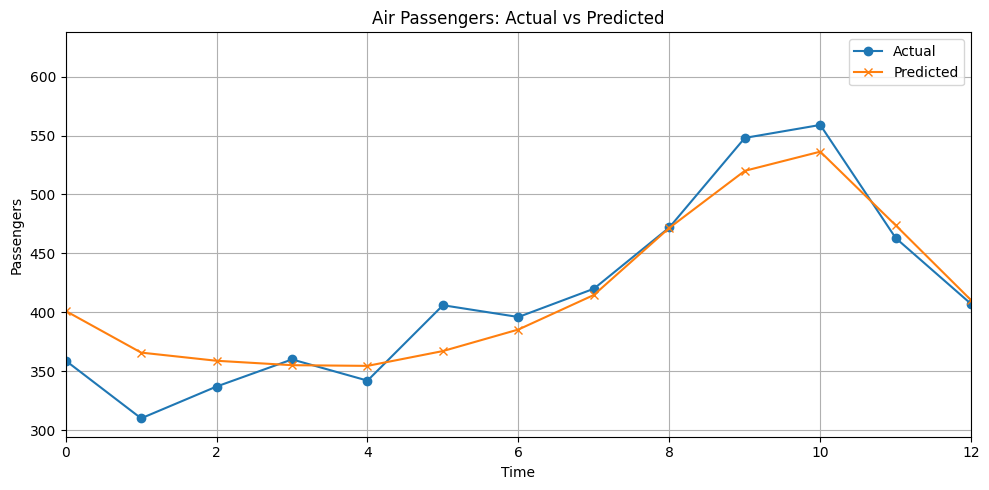

In [ ]:

# 5. Make predictions for the next 12 months and visualize them along with the original data.
plt.figure(figsize=(10, 5))
plt.plot(range(len(actual_inv)), actual_inv, marker='o', label='Actual')
plt.plot(range(len(predicted_inv)), predicted_inv, marker='x', label='Predicted')
plt.title("Air Passengers: Original vs Predicted")
plt.xlabel("Time")
plt.ylabel("Passengers")

plt.xlim(0, 12) # for the next 12 months
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Q. No. 5 Sentiment Analysis on Twitter Data

In [26]:
# 1. Load the dataset and prepare the text data (cleaning, tokenization, padding sequences)

import pandas as pd
import re
import torch
from collections import Counter
import numpy as np
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split



# read data
df = pd.read_csv('dataset/Tweets.csv')
# get the text and label
df = df[['text', 'airline_sentiment']]
# encode the label
label_idx = {'negative': 0, 'neutral': 1, 'positive': 2}
df['label'] = df['airline_sentiment'].map(label_idx)


# data cleaning
def clean_text(txt):
    txt = txt.lower()
    txt = re.sub(r"http\S+", "", txt)      # websute
    txt = re.sub(r"@\w+", "", txt)         # @user
    txt = re.sub(r"[^a-z\s]", "", txt)     # number
    txt = re.sub(r"\s+", " ", txt)         # space
    return txt.strip()
df['clean_text'] = df['text'].apply(clean_text)


# Tokenization
df['tokens'] = df['clean_text'].apply(str.split)
token_list = [token for tokens in df['tokens'] for token in tokens]
vocab_num = Counter(token_list)
vocab = ['<PAD>', '<UNK>'] + [w for w, fre in vocab_num.items() if fre >= 2]
word_to_index = {w: idx for idx, w in enumerate(vocab)}

# token to index
def tokens_to_indices(tokens):
    return [word_to_index.get(token, word_to_index['<UNK>']) for token in tokens]
df['input_ids'] = df['tokens'].apply(tokens_to_indices)



# padding
Len = 32 # sequence length
def pad_sequence(seq, max_len=Len):
    seq = seq[:max_len]
    seq += [word_to_index['<PAD>']] * (max_len - len(seq))
    return seq
df['input_ids_padded'] = df['input_ids'].apply(pad_sequence)



# split training and testing set
X = np.array(df['input_ids_padded'].tolist())
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create data loader
bt_size = 64 # batch size
train_data = TensorDataset(torch.LongTensor(X_train), torch.LongTensor(y_train))
test_data = TensorDataset(torch.LongTensor(X_test), torch.LongTensor(y_test))
train_loader = DataLoader(train_data, batch_size=bt_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=bt_size)


In [27]:
# 2. Build an RNN model with an Embedding layer, at least one recurrent layer (LSTM/GRU), and a Dense Output layer.
import torch.nn as nn
class RNN_1(nn.Module):
    def __init__(self, vocab_size, embedding_dim=100, hidden_dim=128, output_dim=3):
        super().__init__()

        
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)# recurrent layer
        self.fc = nn.Linear(hidden_dim, output_dim)# Dense Output layer
    
    def forward(self, x):
        embedded = self.embedding(x)
        _, (hidden, _) = self.lstm(embedded)
        out = self.fc(hidden[-1])
        return out


In [28]:
#3. Train the model and evaluate its accuracy on a test set.
vocab_size = len(vocab)
model = RNN_1(vocab_size)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# training
for epoch in range(10):
    model.train()
    loss_all = 0
    for xx, yy in train_loader:
        optimizer.zero_grad()
        out = model(xx)
        loss = criterion(out, yy)
        loss.backward()
        optimizer.step()
        loss_all += loss.item()
    print(f'Epoch {epoch+1}, Loss: {loss_all/len(train_loader):.4f}')

#testing
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for xx, yy in test_loader:
        out = model(xx)
        preds = out.argmax(1)
        correct += (preds == yy).sum().item()
        total += yy.size(0)
print(f'Test Accuracy: {correct/total:.4f}')


Epoch 1, Loss: 0.8529
Epoch 2, Loss: 0.6671
Epoch 3, Loss: 0.5807
Epoch 4, Loss: 0.5150
Epoch 5, Loss: 0.4442
Epoch 6, Loss: 0.3825
Epoch 7, Loss: 0.3284
Epoch 8, Loss: 0.2936
Epoch 9, Loss: 0.2531
Epoch 10, Loss: 0.2087
Test Accuracy: 0.7824


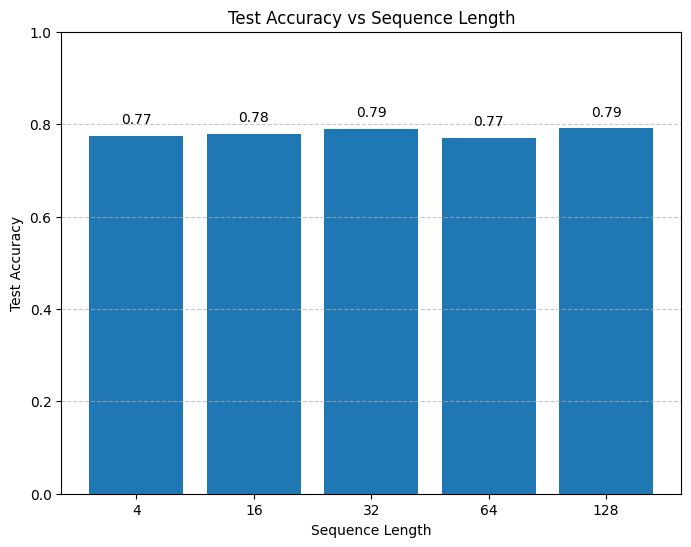

In [4]:
# 4. Experiment with different hyperparameters (sequence length, embedding dimension)

# experiment with different sequence length

import matplotlib.pyplot as plt
def hyper_test(sqe_len=32,embedding_dim=100):

    """
    test the performance of the model with different hyper parameters
    """
    def pad_sequence(seq, max_len=sqe_len):
        seq = seq[:max_len]
        seq += [word_to_index['<PAD>']] * (max_len - len(seq))
        return seq
    
    df['input_ids_padded'] = df['input_ids'].apply(pad_sequence)
    model = RNN_1(vocab_size,embedding_dim=embedding_dim)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # training
    for epoch in range(10):
        model.train()
        loss_all = 0
        for xx, yy in train_loader:
            optimizer.zero_grad()
            out = model(xx)
            loss = criterion(out, yy)
            loss.backward()
            optimizer.step()
            loss_all += loss.item()
        #print(f'Epoch {epoch+1}, Loss: {loss_all/len(train_loader):.4f}')

    #evaluating
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for xx, yy in test_loader:
            out = model(xx)
            preds = out.argmax(1)
            correct += (preds == yy).sum().item()
            total += yy.size(0)
    #print(f'Test Accuracy: {correct/total:.4f}')

    return correct/total


sqe_list=[4,16,32,64,128]
test_acc_list=[]
for sqe_len in sqe_list:
    test_acc_list.append(hyper_test(sqe_len=sqe_len))


# Plotting with value annotations
plt.figure(figsize=(8, 6))
bars = plt.bar([str(s) for s in sqe_list], test_acc_list)
plt.xlabel('Sequence Length')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy vs Sequence Length')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.show()






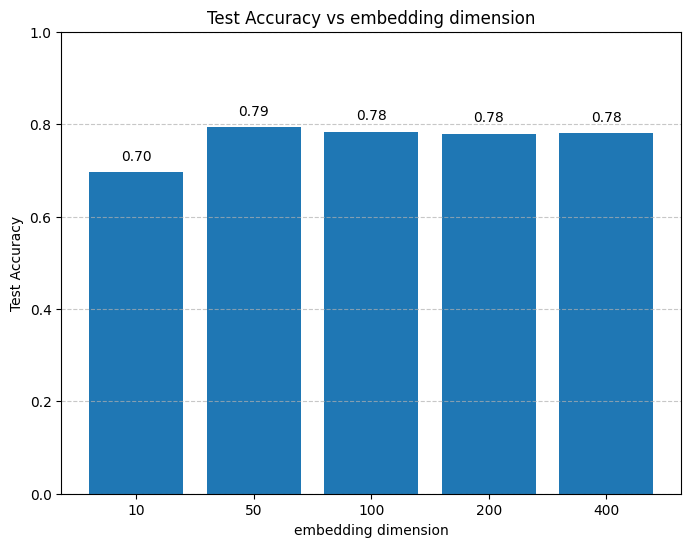

In [5]:
# 4. Experiment with different hyperparameters (sequence length, embedding dimension)

# experiment with different embedding dimension

emd_list=[10,50,100,200,400]
test_acc_list_emd=[]
for emd in emd_list:
    test_acc_list_emd.append(hyper_test(embedding_dim=emd))


# Plotting with value annotations
plt.figure(figsize=(8, 6))
bars = plt.bar([str(s) for s in emd_list], test_acc_list_emd)
plt.xlabel('embedding dimension')
plt.ylabel('Test Accuracy')
plt.title('Test Accuracy vs embedding dimension')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.show()


In [34]:
# 5. Make predictions on sample tweets and evaluate their correctness.
def predict_sentiment(model,text):
    """
    Make predictions on sample tweets
    """
    tokens = clean_text(text).split()
    idx_list = [word_to_index.get(token, word_to_index['<UNK>']) for token in tokens]
    idx_list = pad_sequence(idx_list)
    input_tensor = torch.LongTensor(idx_list).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        out = model(input_tensor)
        pred = out.argmax(1).item()
    idx_to_label = {v: k for k, v in label_idx.items()}
    return idx_to_label[pred]

# samples with the ground truth
sample_list = ["I really enjoy flying with United Airlines!","I really hate the flight","United Airlines is just so so"]
gt=['positive','negative','neutral']

for i in range(len(gt)):
    print(f'Setence: {sample_list[i]} \n Ground_truth: {gt[i]}, Predicted: {predict_sentiment(model,sample_list[i])} \n')


Setence: I really enjoy flying with United Airlines! 
 Ground_truth: positive, Predicted: positive 

Setence: I really hate the flight 
 Ground_truth: negative, Predicted: negative 

Setence: United Airlines is just so so 
 Ground_truth: neutral, Predicted: neutral 



### Q. No. 6 Sequence Generation with RNNs

In [8]:
# 1. Load and preprocess the text data (create character mappings, prepare input-target sequences)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np

# load the text data
with open("dataset/nietzsche.txt", "r", encoding="utf-8") as f:
    text = f.read().lower()


# create character mappings
chars = sorted(list(set(text)))
char_to_index = {ch: idx for idx, ch in enumerate(chars)}
index_to_char = {idx: ch for ch, idx in char_to_index.items()}
vocab_size = len(chars)




# prepare input-target sequences
seq_length = 100
step = 1
input_list = []
target_list = []

for i in range(0, len(text) - seq_length, step):
    input_list.append([char_to_index[ch] for ch in text[i:i + seq_length]])
    target_list.append(char_to_index[text[i + seq_length]])

input_list = torch.tensor(input_list)
target_list = torch.tensor(target_list)

class CharDataset(Dataset):
    """
    create dataset
    """
    def __init__(self, x, y):
        self.x = x
        self.y = y
        
    def __len__(self):
        return len(self.x)
    
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

# create data loader
dataset = CharDataset(input_list, target_list)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)


In [ ]:
# 2. Build a model with at least 2 LSTM layers and appropriate output layer.

class CharLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256):
        super(CharLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers=2,  dropout=0.2,batch_first=True) # 2 layers
        self.fc = nn.Linear(hidden_dim, vocab_size)
        
    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.lstm(x, hidden)
        out = self.fc(out[:, -1, :])  # last step
        return out, hidden




In [ ]:
#3. Train the model to predict the next character in a sequence.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CharLSTM(vocab_size).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)
criterion = nn.CrossEntropyLoss()

num_epochs = 10
model.train()

# training with 10 epochs
for epoch in range(num_epochs):
    total_loss = 0
    for xx, yy in dataloader:
        xx = xx.to(device)
        yy = yy.to(device)
        optimizer.zero_grad()
        output, _ = model(xx)
        loss = criterion(output, yy)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(dataloader):.4f}")


Epoch 1, Loss: 1.7087
Epoch 2, Loss: 1.4831
Epoch 3, Loss: 1.4341
Epoch 4, Loss: 1.4094
Epoch 5, Loss: 1.3951
Epoch 6, Loss: 1.3851
Epoch 7, Loss: 1.3788
Epoch 8, Loss: 1.3756
Epoch 9, Loss: 1.3725
Epoch 10, Loss: 1.3699


In [ ]:
# 4. Implement a text generation function that takes a seed string and generates continuations.
def generate_text(model, start_seq, gen_length=100, temperature=1.0):
    """
    input: model , start_seq: seed string, 
    gen_length: the length of generated content,
    temperature: temperature settings
    """
    model.eval()
    input_list = [char_to_index[ch] for ch in start_seq]
    input_tensor = torch.tensor(input_list).unsqueeze(0).to(device) # create input tnesor

    hidden = None
    generated = start_seq # the final generated text

    for _ in range(gen_length):
        output, hidden = model(input_tensor[:, -seq_length:], hidden)
        output = output / temperature

        prob = torch.nn.functional.softmax(output, dim=1).detach().cpu().numpy().flatten()
        next_idx = np.random.choice(len(chars), p=prob)# random choice by probability
        generated += index_to_char[next_idx]
        input_tensor = torch.cat([input_tensor, torch.tensor([[next_idx]]).to(device)], dim=1)

    return generated


# test
model.eval()

seed = "we are"
generated_text = generate_text(model, start_seq=seed, gen_length=100, temperature=1.0)

print(generated_text)



we are only
a great stander
so far subjective master and ascetent, does he called to this struggle underst


In [16]:
# 5. Experiment with different temperature settings for the sampling.
for temp in [0.5, 1.0, 1.5,2.0]:
    print(f"\n Temperature = {temp}")
    print(generate_text(model, start_seq="he is", gen_length=100, temperature=temp))



 Temperature = 0.5
he is also imposed and struggle and will be respect also a
secret to still necessity and discovery the da

 Temperature = 1.0
he is always no woman to enough to be reason and against one of
all definitely and "nations; or to for
im

 Temperature = 1.5
he is presupposition to], has been--b hoo hypot; devited, not that he domina relalsling him;
but
assume i

 Temperature = 2.0
he is they avoygains,
guart?"):
buouh enlefvour
is mighan
viptibis (a "fix; thate" imaids,
much, and one 
